In [23]:
#Imports numpy for math, matplotlib for plotting, scipy.special for the error function, and the base for the numerical methods and sampling.
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp
import noiseProjectBase as npb

In [24]:
#Generates a deterministic magnetic field consisting of a constant field plus a sine-wave variation.
#Inputs: B0 is the constant field, A is the sine amplitude, omega is the angular frequency, numTrials is the number of trajectories, deltat is the timestep, and tmax is the total evolution time.
#Output: BzData containing the sine-wave magnetic field at every time for every trial.
def sineGenerateBzData(B0, A, omega, numTrials, deltat, tmax):
    BzData = np.zeros((numTrials, int(tmax/deltat)+1))
    for i in range(numTrials):
        for j in range(int(tmax/deltat)+1):
            BzData[i][j] = B0+A*np.sin(omega*deltat*j)
    return BzData

In [25]:
#Generates a deterministic square pulse added to the constant magnetic field between tstart and tend.
#Inputs: B0 is the constant field, A is the pulse amplitude, tstart and tend define the pulse duration, numTrials is the number of trajectories, deltat is the timestep, and tmax is the total evolution time.
#Output: BzData containing the square-pulse magnetic field at every time for every trial.
def squarePulseGenerateBzData(B0, A, tstart, tend, numTrials, deltat, tmax):
    BzData = np.zeros((numTrials, int(tmax/deltat)+1))
    for i in range(numTrials):
        for j in range(int(tmax/deltat)+1):
            if deltat*j<=tend and deltat*j>=tstart:
                BzData[i][j] = B0+A
            else:
                BzData[i][j] = B0
    return BzData

In [26]:
#Generates a deterministic Gaussian pulse centered at tcenter and added to the constant magnetic field.
#Inputs: B0 is the constant field, A is the pulse amplitude, width controls the pulse width, tcenter sets the pulse center, numTrials is the number of trajectories, deltat is the timestep, and tmax is the total evolution time.
#Output: BzData containing the Gaussian-pulse magnetic field at every time for every trial.
def gaussianPulseGenerateBzData(B0, A, width, tcenter, numTrials, deltat, tmax):
    BzData = np.zeros((numTrials, int(tmax/deltat)+1))
    for i in range(numTrials):
        for j in range(int(tmax/deltat)+1):
            BzData[i][j] = B0+A*np.exp(-((deltat*j-tcenter)**2)/(2*width*width))
    return BzData

In [27]:
#Calculates the analytical X expectation value for a magnetic field containing a sinusoidal variation.
#Inputs: B0 is the constant field, A is the sine amplitude, omega is the angular frequency, alpha and beta are the initial spin amplitudes, and timeList contains the evolution times.
#Output: Analytical X expectation value at every time.
def expectedAverageXSine(B0, A, omega, alpha, beta, timeList):
    time = np.array(timeList)
    return 2*np.real(np.conjugate(alpha)*beta*np.exp(2*1.0j*B0*time-(2*1.0j*A/omega)*(np.cos(omega*time)-1)))

In [28]:
#Calculates the analytical X expectation value for a square magnetic-field pulse.
#Inputs: B0 is the constant field, A is the pulse amplitude, alpha and beta are the initial spin amplitudes, tstart and tend define the pulse, and timeList contains the evolution times.
#Output: Analytical X expectation value at every time.
def expectedAverageXSquarePulse(B0, A, alpha, beta, tstart, tend, timeList):
    XList = []
    time = np.array(timeList)

    #Calculates the accumulated phase differently before, during, and after the square pulse.
    for time in timeList:
        if time<tstart:
            Bz = B0*time
        elif time<tend:
            Bz = B0*time+A*(time-tstart)
        else:
            Bz = B0*time+A*(tend-tstart)
        XList.append(2*np.real(np.conjugate(alpha)*beta*np.exp(2*1.0j*Bz)))
    return XList

In [29]:
#Calculates the analytical X expectation value for a Gaussian magnetic-field pulse.
#Inputs: B0 is the constant field, A is the pulse amplitude, width controls the pulse width, alpha and beta are the initial spin amplitudes, tcenter sets the pulse center, and timeList contains the evolution times.
#Output: Analytical X expectation value at every time.
def expectedAverageXGaussianPulse(B0, A, width, alpha, beta, tcenter, timeList):
    time = np.array(timeList)
    return 2*np.real(alpha*beta*np.exp(2*1.0j*(B0*time+A*width*np.sqrt(np.pi/2)*(sp.erf((time-tcenter)/(width*np.sqrt(2)))-sp.erf(-tcenter/(width*np.sqrt(2)))))))

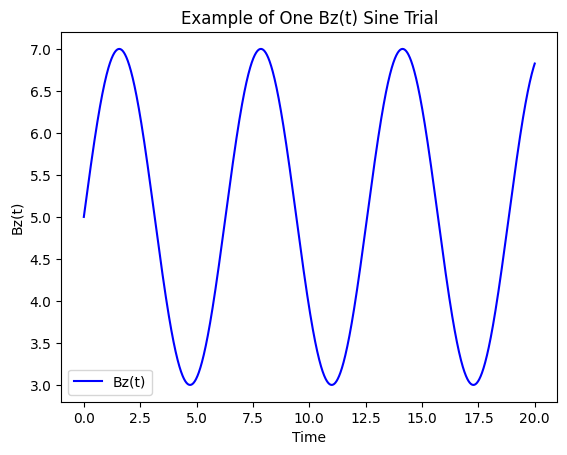

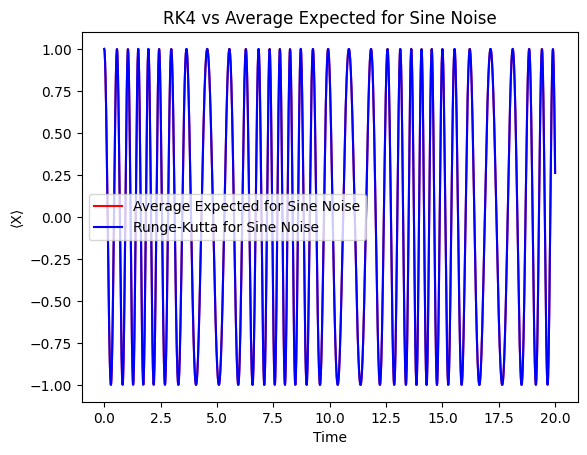

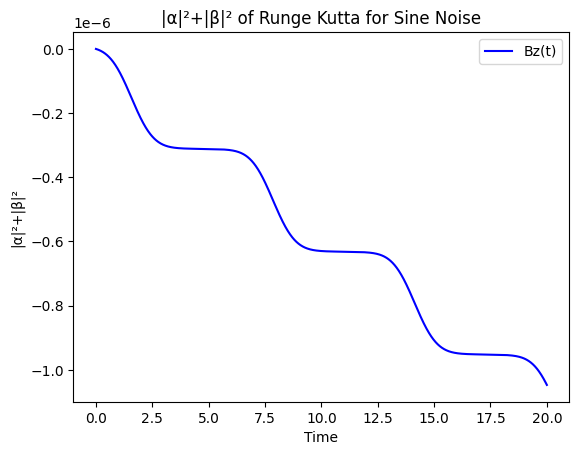

In [30]:
#Defines the initial equal-superposition spin state and simulation parameters for a single sine-wave magnetic field.
alpha0 = 1.0/np.sqrt(2)
beta0 = 1.0/np.sqrt(2)
Bx = 0.0
By = 0.0
B0 = 5.0
deltat = 0.01
tmax = 20
sigma = 0.5
A = 2.0
omega = 1.0
numTrials = 1000

#Generates the sine-wave magnetic field and evolves the spin using RK4.
BzData1 = sineGenerateBzData(B0, A, omega, numTrials, deltat, tmax)
BzList3, newTimeList3, newAlphaList3, newBetaList3, newXList3, newNormList3 = npb.Bzaverages(alpha0, beta0, Bx, By, BzData1, deltat, tmax, 3)

#Calculates the analytical X expectation value for comparison with RK4.
expectedXList1 = expectedAverageXSine(B0, A, omega, alpha0, beta0, newTimeList3)

#Plots one example of the deterministic sine-wave magnetic field.
plt.figure(1)
plt.plot(newTimeList3, BzData1[0], label="Bz(t)", color="blue")
plt.title("Example of One Bz(t) Sine Trial")
plt.xlabel("Time")
plt.ylabel("Bz(t)")
plt.legend()
plt.show()

#Compares the RK4 spin evolution with the analytical result.
plt.figure(2)
plt.plot(newTimeList3, expectedXList1, label="Average Expected for Sine Noise", color="red")
plt.plot(newTimeList3, newXList3, label="Runge-Kutta for Sine Noise", color="blue")
plt.title("RK4 vs Average Expected for Sine Noise")
plt.xlabel("Time")
plt.ylabel("⟨X⟩")
plt.legend()
plt.show()

#Plots the normalization error during the RK4 evolution.
plt.figure(3)
plt.plot(newTimeList3, newNormList3, label="Bz(t)", color="blue")
plt.title("|α|²+|β|² of Runge Kutta for Sine Noise")
plt.xlabel("Time")
plt.ylabel("|α|²+|β|²")
plt.legend()
plt.show()

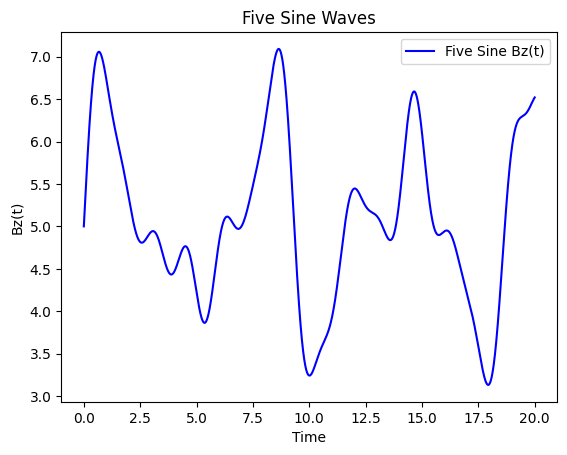

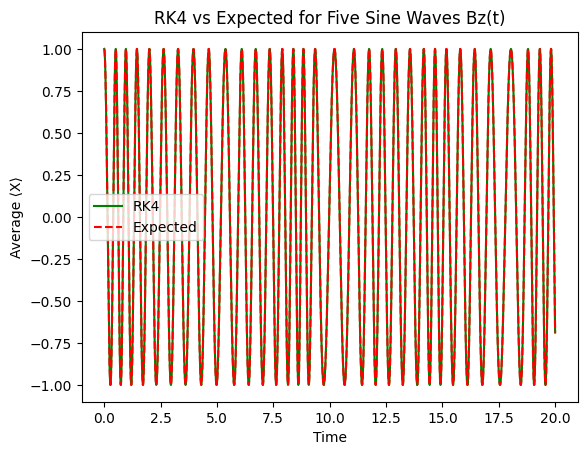

In [31]:
#Defines the initial spin state and simulation parameters for a magnetic field made from five sine waves.
alpha0 = 1/np.sqrt(2)
beta0 = 1/np.sqrt(2)
Bx = 0.0
By = 0.0
B0 = 5.0
AList = [1.0, 0.7, 0.5, 0.3, 0.2]
omegaList = [1.0, 1.7, 2.3, 3.1, 4.4]
deltat = 0.001
tmax = 20.0
numTrials = 100
BzDataFiveSine = []

#Constructs the total magnetic field by adding five sine waves to B0.
for i in range(numTrials):
    BzList = []
    for j in range(int(tmax/deltat)+1):
        t = j*deltat
        Bz = B0
        for k in range(len(AList)):
            Bz = Bz+AList[k]*np.sin(omegaList[k]*t)
        BzList.append(Bz)
    BzDataFiveSine.append(BzList)

BzDataFiveSine = np.array(BzDataFiveSine)

#Evolves the spin under the five-sine magnetic field using RK4.
BzListFiveSine, newTimeListFiveSine, newAlphaListFiveSine, newBetaListFiveSine, newXListFiveSine, newNormListFiveSine = npb.Bzaverages(alpha0, beta0, Bx, By, BzDataFiveSine, deltat, tmax, 3)

#Calculates the analytical accumulated phase and X expectation value from all five sine components.
expectedXListFiveSine = []

for t in newTimeListFiveSine:
    phi = B0*t
    for k in range(len(AList)):
        phi = phi+(AList[k]/omegaList[k])*(1-np.cos(omegaList[k]*t))
    x = 2*np.real(np.conjugate(alpha0)*beta0*np.exp(2*1.0j*phi))
    expectedXListFiveSine.append(x)

#Plots the magnetic field created by the five sine waves.
plt.figure(1)
plt.plot(newTimeListFiveSine, BzDataFiveSine[0], label="Five Sine Bz(t)", color="blue")
plt.title("Five Sine Waves")
plt.xlabel("Time")
plt.ylabel("Bz(t)")
plt.legend()
plt.show()

#Compares the RK4 result with the analytical prediction.
plt.figure(2)
plt.plot(newTimeListFiveSine, newXListFiveSine, label="RK4", color="green")
plt.plot(newTimeListFiveSine, expectedXListFiveSine, label="Expected", color="red", linestyle="--")
plt.title("RK4 vs Expected for Five Sine Waves Bz(t)")
plt.xlabel("Time")
plt.ylabel("Average ⟨X⟩")
plt.legend()
plt.show()

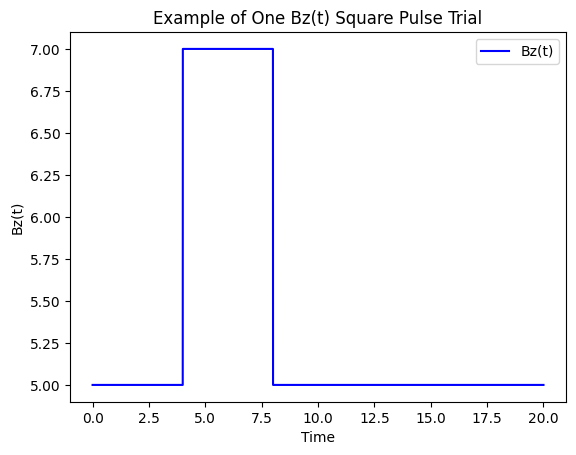

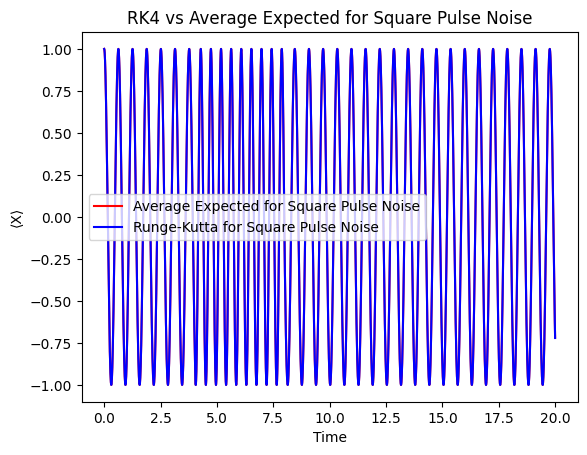

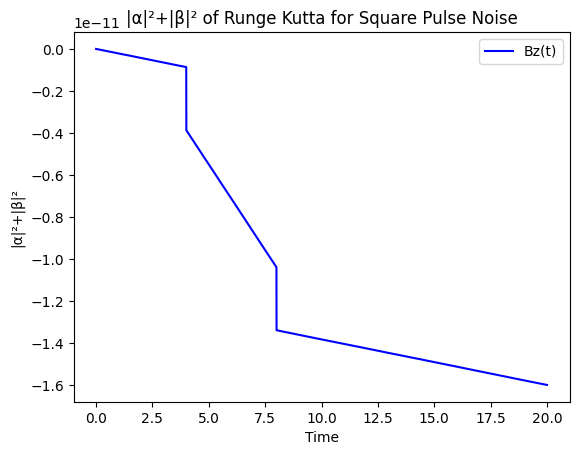

In [32]:
#Defines the initial spin state and simulation parameters for a square magnetic-field pulse.
alpha0 = 1.0/np.sqrt(2)
beta0 = 1.0/np.sqrt(2)
Bx = 0.0
By = 0.0
B0 = 5.0
deltat = 0.001
tmax = 20
sigma = 0.5
A = 2.0
tstart = 4.0
tend = 8.0
numTrials = 1000

#Generates the square-pulse magnetic field and evolves the spin using RK4.
BzData2 = squarePulseGenerateBzData(B0, A, tstart, tend, numTrials, deltat, tmax)
BzList3, newTimeList3, newAlphaList3, newBetaList3, newXList3, newNormList3 = npb.Bzaverages(alpha0, beta0, Bx, By, BzData2, deltat, tmax, 3)

#Calculates the analytical X expectation value for comparison.
expectedXList2 = expectedAverageXSquarePulse(B0, A, alpha0, beta0, tstart, tend, newTimeList3)

#Plots one example of the square-pulse magnetic field.
plt.figure(1)
plt.plot(newTimeList3, BzData2[0], label="Bz(t)", color="blue")
plt.title("Example of One Bz(t) Square Pulse Trial")
plt.xlabel("Time")
plt.ylabel("Bz(t)")
plt.legend()
plt.show()

#Compares the RK4 spin evolution with the analytical result.
plt.figure(2)
plt.plot(newTimeList3, expectedXList2, label="Average Expected for Square Pulse Noise", color="red")
plt.plot(newTimeList3, newXList3, label="Runge-Kutta for Square Pulse Noise", color="blue")
plt.title("RK4 vs Average Expected for Square Pulse Noise")
plt.xlabel("Time")
plt.ylabel("⟨X⟩")
plt.legend()
plt.show()

#Plots the normalization error during the RK4 evolution.
plt.figure(3)
plt.plot(newTimeList3, newNormList3, label="Bz(t)", color="blue")
plt.title("|α|²+|β|² of Runge Kutta for Square Pulse Noise")
plt.xlabel("Time")
plt.ylabel("|α|²+|β|²")
plt.legend()
plt.show()

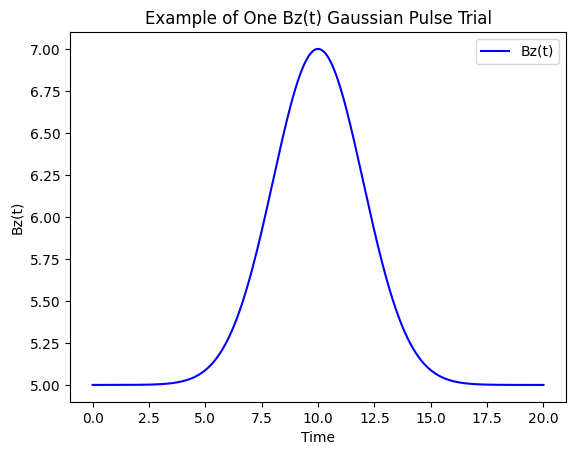

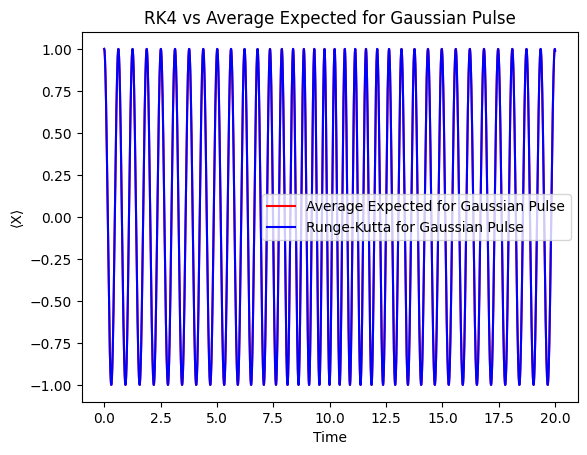

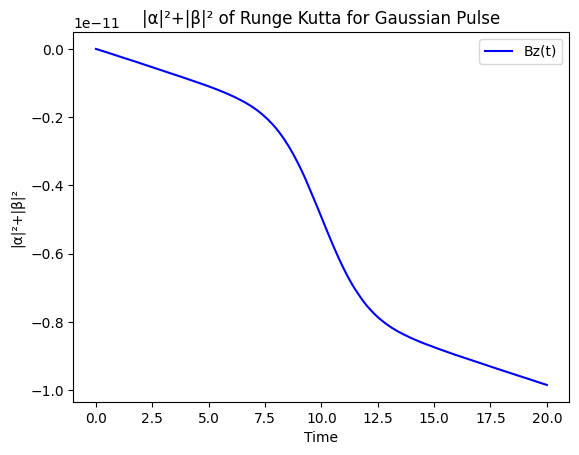

In [33]:
#Defines the initial spin state and simulation parameters for a Gaussian magnetic-field pulse.
alpha0 = 1.0/np.sqrt(2)
beta0 = 1.0/np.sqrt(2)
Bx = 0.0
By = 0.0
B0 = 5.0
deltat = 0.001
tmax = 20
sigma = 0.5
A = 2.0
tcenter = 10.0
width = 2.0
numTrials = 1000

#Generates the Gaussian-pulse magnetic field and evolves the spin using RK4.
BzData3 = gaussianPulseGenerateBzData(B0, A, width, tcenter, numTrials, deltat, tmax)
BzList3, newTimeList3, newAlphaList3, newBetaList3, newXList3, newNormList3 = npb.Bzaverages(alpha0, beta0, Bx, By, BzData3, deltat, tmax, 3)

#Calculates the analytical X expectation value for comparison.
expectedXList3 = expectedAverageXGaussianPulse(B0, A, width, alpha0, beta0, tcenter, newTimeList3)

#Plots one example of the Gaussian-pulse magnetic field.
plt.figure(1)
plt.plot(newTimeList3, BzData3[0], label="Bz(t)", color="blue")
plt.title("Example of One Bz(t) Gaussian Pulse Trial")
plt.xlabel("Time")
plt.ylabel("Bz(t)")
plt.legend()
plt.show()

#Compares the RK4 spin evolution with the analytical result.
plt.figure(2)
plt.plot(newTimeList3, expectedXList3, label="Average Expected for Gaussian Pulse", color="red")
plt.plot(newTimeList3, newXList3, label="Runge-Kutta for Gaussian Pulse", color="blue")
plt.title("RK4 vs Average Expected for Gaussian Pulse")
plt.xlabel("Time")
plt.ylabel("⟨X⟩")
plt.legend()
plt.show()

#Plots the normalization error during the RK4 evolution.
plt.figure(3)
plt.plot(newTimeList3, newNormList3, label="Bz(t)", color="blue")
plt.title("|α|²+|β|² of Runge Kutta for Gaussian Pulse")
plt.xlabel("Time")
plt.ylabel("|α|²+|β|²")
plt.legend()
plt.show()